In [1]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0]

print(f'Węzły: {data.num_nodes}')
print(f'Krawędzie: {data.num_edges}')
print(f'Cechy węzła: {data.num_node_features}')
print(f'Klas: {dataset.num_classes}')
print(f'Węzły treningowe: {data.train_mask.sum()}')

Węzły: 2708
Krawędzie: 10556
Cechy węzła: 1433
Klas: 7
Węzły treningowe: 140


# Baseline GCN implementation

In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, 
                 hidden_channels, 
                 out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 
                             hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 
                             out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

### GCN training

In [3]:
model = GCN(dataset.num_features, 64, dataset.num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

for epoch in range(200):
    loss = train()
    acc = test()
    if epoch % 20 == 0:
        print(f'Epoch {epoch}: Loss={loss:.4f}, Acc={acc:.4f}')

Epoch 0: Loss=1.9410, Acc=0.6010
Epoch 20: Loss=0.0082, Acc=0.8000
Epoch 40: Loss=0.0009, Acc=0.7900
Epoch 60: Loss=0.0005, Acc=0.7920
Epoch 80: Loss=0.0008, Acc=0.7950
Epoch 100: Loss=0.0003, Acc=0.7880
Epoch 120: Loss=0.0002, Acc=0.7880
Epoch 140: Loss=0.0003, Acc=0.7950
Epoch 160: Loss=0.0002, Acc=0.7950
Epoch 180: Loss=0.0002, Acc=0.7940


# Create split

In [4]:
import torch
import numpy as np
from collections import defaultdict

def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)

    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]

    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True

    return train_mask

# Uruchomienie każdego scenariusza 5 razy z różnym seedem
ratios = [0.05, 0.10, 0.20]
seeds = [42, 123, 456, 789, 1000]
results = defaultdict(list)

for ratio in ratios:
    for seed in seeds:
        data.train_mask = create_split(data, ratio, seed)
        
        model = GCN(dataset.num_features, 64, dataset.num_classes)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        
        for epoch in range(200):
            train()
        
        acc = test()
        results[ratio].append(acc)
        print(f'Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

for ratio, accs in results.items():
    mean = np.mean(accs)
    std = np.std(accs)
    print(f'{ratio:.0%}: {mean:.4f} ± {std:.4f}')

Ratio: 5%, Seed: 42, Acc: 0.7900
Ratio: 5%, Seed: 123, Acc: 0.7980
Ratio: 5%, Seed: 456, Acc: 0.7750
Ratio: 5%, Seed: 789, Acc: 0.8170
Ratio: 5%, Seed: 1000, Acc: 0.7810
Ratio: 10%, Seed: 42, Acc: 0.8100
Ratio: 10%, Seed: 123, Acc: 0.7910
Ratio: 10%, Seed: 456, Acc: 0.8290
Ratio: 10%, Seed: 789, Acc: 0.8160
Ratio: 10%, Seed: 1000, Acc: 0.8300
Ratio: 20%, Seed: 42, Acc: 0.8410
Ratio: 20%, Seed: 123, Acc: 0.8060
Ratio: 20%, Seed: 456, Acc: 0.8340
Ratio: 20%, Seed: 789, Acc: 0.8140
Ratio: 20%, Seed: 1000, Acc: 0.8420
5%: 0.7922 ± 0.0147
10%: 0.8152 ± 0.0143
20%: 0.8274 ± 0.0147


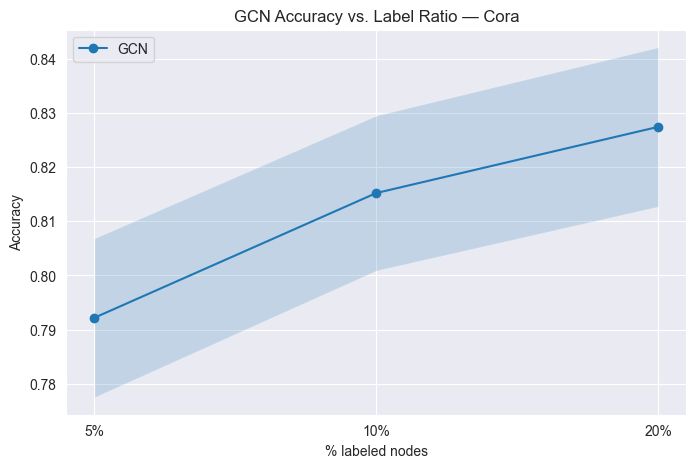

In [5]:
import matplotlib.pyplot as plt

means = [np.mean(results[r]) for r in ratios]
stds = [np.std(results[r]) for r in ratios]
labels = ['5%', '10%', '20%']

plt.figure(figsize=(8, 5))
plt.plot(labels, means, marker='o', label='GCN')
plt.fill_between(labels, 
                 [m-s for m,s in zip(means,stds)],
                 [m+s for m,s in zip(means,stds)], 
                 alpha=0.2)
plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('GCN Accuracy vs. Label Ratio — Cora')
plt.legend()
import os
os.makedirs('results', exist_ok=True)
plt.savefig('results/gcn_label_ratio.png')
plt.show()

# GAT

In [6]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, 
                 hidden_channels, 
                 out_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_channels, 
                             hidden_channels, 
                             heads=heads, 
                             dropout=0.6)
        self.conv2 = GATConv(hidden_channels * heads, 
                             out_channels, 
                             heads=1, 
                             dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [7]:
def train_model(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test_model(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

In [8]:
all_results = {'GCN': results}  # zachowaj wyniki GCN
gat_results = defaultdict(list)

for ratio in ratios:
    for seed in seeds:
        data.train_mask = create_split(data, ratio, seed)
        
        model = GAT(dataset.num_features, 8, dataset.num_classes)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
        
        for epoch in range(200):
            train()
        
        acc = test()
        gat_results[ratio].append(acc)
        print(f'GAT | Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

all_results['GAT'] = gat_results

for ratio, accs in gat_results.items():
    print(f'{ratio:.0%}: {np.mean(accs):.4f} ± {np.std(accs):.4f}')

GAT | Ratio: 5%, Seed: 42, Acc: 0.8070
GAT | Ratio: 5%, Seed: 123, Acc: 0.8130
GAT | Ratio: 5%, Seed: 456, Acc: 0.8000
GAT | Ratio: 5%, Seed: 789, Acc: 0.8170
GAT | Ratio: 5%, Seed: 1000, Acc: 0.7920
GAT | Ratio: 10%, Seed: 42, Acc: 0.8340
GAT | Ratio: 10%, Seed: 123, Acc: 0.8090
GAT | Ratio: 10%, Seed: 456, Acc: 0.8200
GAT | Ratio: 10%, Seed: 789, Acc: 0.8260
GAT | Ratio: 10%, Seed: 1000, Acc: 0.8150
GAT | Ratio: 20%, Seed: 42, Acc: 0.8480
GAT | Ratio: 20%, Seed: 123, Acc: 0.8360
GAT | Ratio: 20%, Seed: 456, Acc: 0.8560
GAT | Ratio: 20%, Seed: 789, Acc: 0.8300
GAT | Ratio: 20%, Seed: 1000, Acc: 0.8540
5%: 0.8058 ± 0.0090
10%: 0.8208 ± 0.0087
20%: 0.8448 ± 0.0102


# GCC vs GAT    

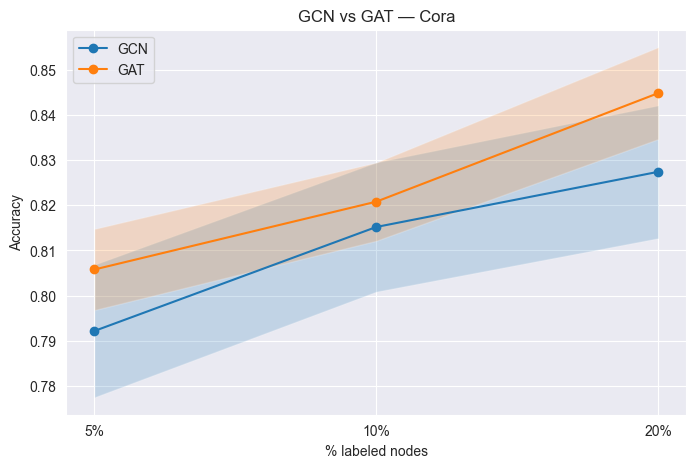

In [9]:
plt.figure(figsize=(8, 5))

for model_name, res in all_results.items():
    means = [np.mean(res[r]) for r in ratios]
    stds = [np.std(res[r]) for r in ratios]
    plt.plot(labels, means, marker='o', label=model_name)
    plt.fill_between(labels,
                     [m-s for m,s in zip(means,stds)],
                     [m+s for m,s in zip(means,stds)],
                     alpha=0.2)

plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('GCN vs GAT — Cora')
plt.legend()
plt.savefig('results/gcn_vs_gat.png')
plt.show()

# Confusion matrix

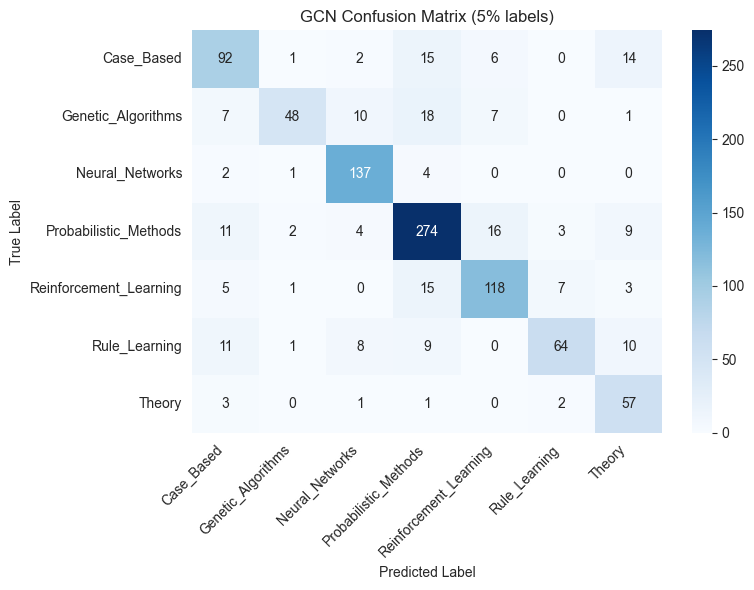

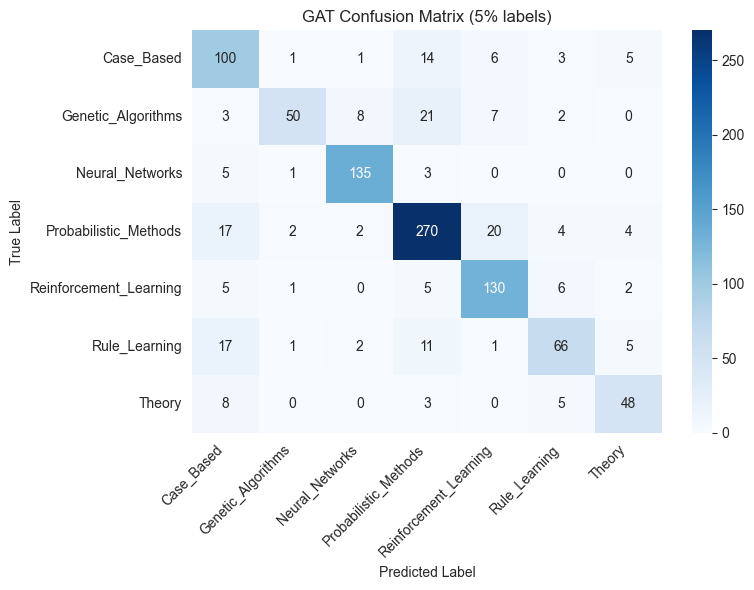

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def get_confusion_matrix(model_class, model_kwargs, label_ratio=0.05, seed=42):
    data.train_mask = create_split(data, label_ratio, seed)
    
    model = model_class(**model_kwargs)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
    
    y_true = data.y[data.test_mask].numpy()
    y_pred = pred[data.test_mask].numpy()
    
    return confusion_matrix(y_true, y_pred)

class_names = ['Case_Based', 'Genetic_Algorithms', 'Neural_Networks', 
               'Probabilistic_Methods', 'Reinforcement_Learning', 
               'Rule_Learning', 'Theory']

def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'results/{filename}.png')
    plt.show()

# GCN
cm_gcn = get_confusion_matrix(
    GCN, 
    {'in_channels': dataset.num_features, 'hidden_channels': 64, 'out_channels': dataset.num_classes}
)
plot_confusion_matrix(cm_gcn, 'GCN Confusion Matrix (5% labels)', 'cm_gcn')

# GAT
cm_gat = get_confusion_matrix(
    GAT,
    {'in_channels': dataset.num_features, 'hidden_channels': 8, 'out_channels': dataset.num_classes}
)
plot_confusion_matrix(cm_gat, 'GAT Confusion Matrix (5% labels)', 'cm_gat')

# t-SNE

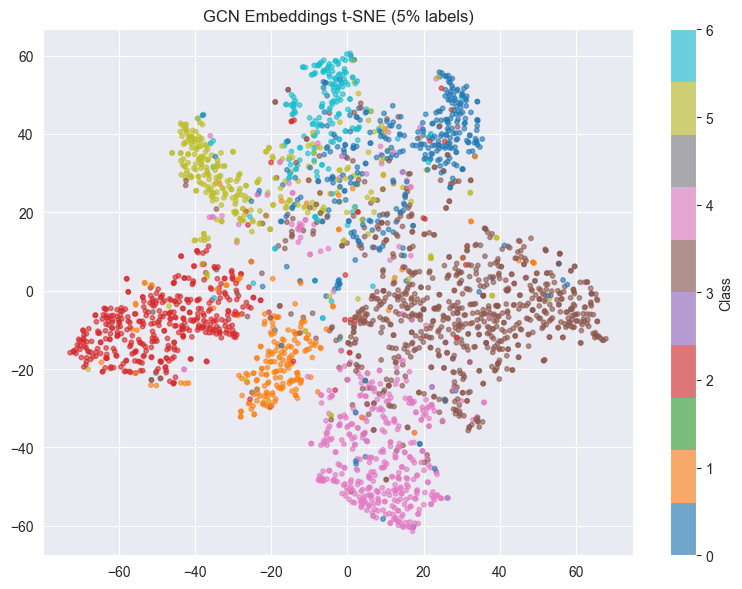

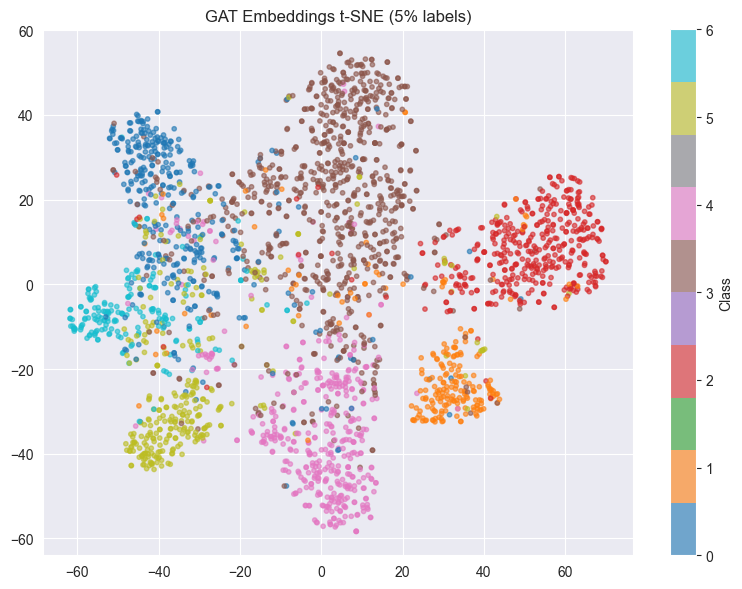

In [11]:
from sklearn.manifold import TSNE

def get_embeddings(model):
    model.eval()
    with torch.no_grad():
        x = data.x
        edge_index = data.edge_index
        
        emb = model.conv1(x, edge_index)
        emb = F.relu(emb)
    return emb.numpy()

def plot_tsne(embeddings, title, filename):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    emb_2d = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], 
                         c=data.y.numpy(), 
                         cmap='tab10', 
                         alpha=0.6, 
                         s=10)
    plt.colorbar(scatter, label='Class')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'results/{filename}.png')
    plt.show()

data.train_mask = create_split(data, 0.05, seed=42)

gcn_model = GCN(dataset.num_features, 64, dataset.num_classes)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01)
for epoch in range(200):
    gcn_model.train()
    optimizer.zero_grad()
    out = gcn_model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

gat_model = GAT(dataset.num_features, 8, dataset.num_classes)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)
for epoch in range(200):
    gat_model.train()
    optimizer.zero_grad()
    out = gat_model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

# t-SNE
gcn_emb = get_embeddings(gcn_model)
gat_emb = get_embeddings(gat_model)

plot_tsne(gcn_emb, 'GCN Embeddings t-SNE (5% labels)', 'tsne_gcn')
plot_tsne(gat_emb, 'GAT Embeddings t-SNE (5% labels)', 'tsne_gat')

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import numpy as np

def get_embeddings(model):
    model.eval()
    with torch.no_grad():
        x = data.x
        edge_index = data.edge_index

        # embedding po pierwszej warstwie
        x = model.conv1(x, edge_index)
        x = F.relu(x)

    return x.cpu().numpy()

def tsne_metrics(model, name):
    embeddings = get_embeddings(model)
    labels = data.y.cpu().numpy()

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(embeddings)

    sil_original = silhouette_score(embeddings, labels)
    sil_tsne = silhouette_score(tsne_result, labels)

    print(f"{name}")
    print(f"Silhouette score embeddingów: {sil_original:.4f}")
    print(f"Silhouette score po t-SNE: {sil_tsne:.4f}")

In [13]:
tsne_metrics(gcn_model, "GCN")
tsne_metrics(gat_model, "GAT")

GCN
Silhouette score embeddingów: 0.1667
Silhouette score po t-SNE: 0.1983
GAT
Silhouette score embeddingów: 0.1838
Silhouette score po t-SNE: 0.2348
